We'll test
- LightGBM
- Catboost

In [42]:
from pathlib import Path
import joblib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import lightgbm as lgb

import ast

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.utils.validation import check_is_fitted

from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, RepeatedStratifiedKFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV


from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    average_precision_score,
    PrecisionRecallDisplay
)

from sklearn.preprocessing import MultiLabelBinarizer, label_binarize, OneHotEncoder, LabelEncoder
from collections import Counter
from sklearn.dummy import DummyClassifier

from collections import defaultdict

from lightgbm import LGBMClassifier

In [3]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [4]:
data_dir = Path('../../results')

#Load dfs
train = pd.read_csv(data_dir / 'train_clean.csv')
test = pd.read_csv(data_dir / 'test_clean.csv')

In [5]:
# Define target variables

y_train_rating = train['rating']
y_test_rating = test['rating']

y_train_titleType = train['titleType']
y_test_titleType = test['titleType']

In [6]:
# Create copies of the dataframes to manipulate
df_train = train.copy()
df_test = test.copy()

# Rating

## Preprocessing

In [7]:
def check_columns(train_df, test_df):
    train_cols = set(train_df.columns)
    test_cols = set(test_df.columns)
    if train_cols == test_cols:
        print("Train and test columns match.")
    else:
        print("Train and test columns DO NOT match.")
        print("Only in train:", train_cols - test_cols)
        print("Only in test:", test_cols - train_cols)

check_columns(df_train, df_test)


Train and test columns match.


In [8]:
# drop target variables
df_train.drop(columns=['rating', 'averageRating'], inplace=True) 
df_test.drop(columns=['rating', 'averageRating'], inplace=True)

check_columns(df_train, df_test)
df_train.columns

Train and test columns match.


Index(['originalTitle', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber', 'regions',
       'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio',
       'hasAwards', 'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

In [9]:
num_cols = df_train.dtypes[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')].index
bool_cols = df_train.dtypes[df_train.dtypes == 'bool'].index
cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions']).index #drop the target var and lists

In [10]:
num_cols, bool_cols, cat_cols #NB: cat_cols only contains titleType, this is for rating as a target

(Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
        'totalCredits', 'numRegions', 'companiesNumber', 'externalLinks',
        'writerCredits', 'numGenres', 'criticReviewsRatio'],
       dtype='object'),
 Index(['canHaveEpisodes', 'hasAwards', 'hasAwardsOrNominations', 'hasVideos',
        'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
        'hasQuotes', 'moreCountriesOfOrigin'],
       dtype='object'),
 Index(['titleType'], dtype='object'))

In [11]:
# Lists: countryOfOrigin, genres, regions	
df_train['countryOfOrigin'] = df_train['countryOfOrigin'].apply(ast.literal_eval)
df_train['genres'] = df_train['genres'].apply(ast.literal_eval)
df_train['regions'] = df_train['regions'].apply(ast.literal_eval)

df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['regions'] = df_test['regions'].apply(ast.literal_eval)

In [12]:
def clean_geo(geo, top_geo):
    """    Clean geographical data by replacing less common entries with 'Other'."""
    return [c if c in top_geo else "Other" for c in geo]

In [13]:
all_countries = [country for countries in df_train['countryOfOrigin'] for country in countries]
country_counts = Counter(all_countries) #Counter: dictionary 'country':count

top_n_countries = 25
top_countries = set([country for country, _ in country_counts.most_common(top_n_countries)]) 

df_train['country_cleaned'] = df_train['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)

In [14]:
all_regions = [region for regions in df_train['regions'] for region in regions]
region_counts = Counter(all_regions) #Counter: dictionary 'country':count

top_n_regions = 25
top_regions = set([region for region, _ in region_counts.most_common(top_n_regions)])

df_train['region_cleaned'] = df_train['regions'].apply(clean_geo, top_geo=top_regions)
df_test['region_cleaned'] = df_test['regions'].apply(clean_geo, top_geo=top_regions)

In [15]:
# Custom transformer for MultiLabelBinarizer
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self
    
    def transform(self, X):
        return self.mlb.transform(X)
    
    def get_feature_names_out(self, input_features=None):
        'Return feature names for output features'
        check_is_fitted(self.mlb)
        return np.array([f"mlb__{label}" for label in self.mlb.classes_])

In [16]:
def build_preprocessor(num_cols, bool_cols, cat_cols):
    return ColumnTransformer(
        transformers=[
            ('num', 'passthrough', num_cols), #TREES: NO SCALING NEEDED
            ('bool', 'passthrough', bool_cols),
            ('cat', OneHotEncoder(), cat_cols),  # No need for drop='first': RF handles redundant feats
            ('countries', MultiLabelBinarizerTransformer(), 'country_cleaned'),
            ('genres', MultiLabelBinarizerTransformer(), 'genres'),
            ('regions', MultiLabelBinarizerTransformer(), 'region_cleaned')
        ]
    )

## Pipeline

In [ ]:
pipeline_rating = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', LGBMClassifier(random_state=42, objective='multiclass', num_class=10))
])

## Hyperparameter Tuning

In [ ]:
param_list_100 = {
    'clf__n_estimators': [100],
    'clf__boosting_type': ['gbdt', 'goss', 'dart'],
    'clf__num_leaves': np.arange(20, 100, 10),
    'clf__max_depth': [-1] + list(np.arange(3, 13)),
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__reg_alpha': [0, 0.01, 0.1, 1],
    'clf__reg_lambda': [0, 0.01, 0.1, 1]
}

param_list_300 = {
    'clf__n_estimators': [300],
    'clf__boosting_type': ['gbdt', 'goss', 'dart'],
    'clf__num_leaves': np.arange(20, 100, 10),
    'clf__max_depth': [-1] + list(np.arange(3, 13)),
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__reg_alpha': [0, 0.01, 0.1, 1],
    'clf__reg_lambda': [0, 0.01, 0.1, 1]
}

# 500 estimators resulted too computationally expensive
"""
param_list_500 = {
    'clf__n_estimators': [500],
    'clf__boosting_type': ['gbdt', 'goss', 'dart'],
    'clf__num_leaves': np.arange(20, 100, 10),
    'clf__max_depth': [-1] + list(np.arange(3, 13)),
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__reg_alpha': [0, 0.01, 0.1, 1],
    'clf__reg_lambda': [0, 0.01, 0.1, 1]
}
"""

In [19]:
random_search_rating_100 = RandomizedSearchCV(
    pipeline_rating,
    param_distributions=param_list_100,
    n_iter=100,
    cv=3,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_rating_100.fit(df_train, y_train_rating)

print(f"BEST MODEL:")
best_index_rating_100 = random_search_rating_100.best_index_
train_macro_f1_rating_100 = random_search_rating_100.cv_results_['mean_train_f1_macro'][best_index_rating_100]

print(f"Validation macro F1: {random_search_rating_100.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_rating_100:.3f}")
print(f"Best parameters: {random_search_rating_100.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2099
[LightGBM] [Info] Number of data points in the train set: 104664, number of used features: 110
[LightGBM] [Info] Start training from score -7.368856
[LightGBM] [Info] Start training from score -5.726628
[LightGBM] [Info] Start training from score -4.863948
[LightGBM] [Info] Start training from score -3.771959
[LightGBM] [Info] Start training from score -2.804508
[LightGBM] [Info] Start training from score -1.939045
[LightGBM] [Info] Start training from score -1.344748
[LightGBM] [Info] Start training from score -1.126249
[LightGBM] [Info] Start training from score -1.911529
[LightGBM] [Info] Start training from score -3.564891
[LightGBM] [Warning] No further splits wit

In [20]:
cv_results_rating_100 = pd.DataFrame(random_search_rating_100.cv_results_)
cv_results_rating_100['overfitting_gap'] = cv_results_rating_100['mean_train_f1_macro'] - cv_results_rating_100['mean_test_f1_macro']

In [34]:
pd.set_option("display.max_colwidth", None)

In [35]:
cv_results_rating_100.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(25)[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']]

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
94,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 0.01, 'clf__num_leaves': 50, 'clf__n_estimators': 100, 'clf__max_depth': 10, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.644436,0.270036,0.374401
84,"{'clf__reg_lambda': 0.01, 'clf__reg_alpha': 0, 'clf__num_leaves': 70, 'clf__n_estimators': 100, 'clf__max_depth': -1, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.732852,0.269845,0.463006
87,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 0.01, 'clf__num_leaves': 70, 'clf__n_estimators': 100, 'clf__max_depth': 12, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}",0.603396,0.264079,0.339317
12,"{'clf__reg_lambda': 0.01, 'clf__reg_alpha': 0, 'clf__num_leaves': 70, 'clf__n_estimators': 100, 'clf__max_depth': -1, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}",0.629754,0.263740,0.366014
97,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 1, 'clf__num_leaves': 40, 'clf__n_estimators': 100, 'clf__max_depth': 10, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.572371,0.263702,0.308669
54,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 1, 'clf__num_leaves': 60, 'clf__n_estimators': 100, 'clf__max_depth': 10, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}",0.518215,0.258258,0.259957
17,"{'clf__reg_lambda': 0, 'clf__reg_alpha': 0, 'clf__num_leaves': 70, 'clf__n_estimators': 100, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.648159,0.255636,0.392523
85,"{'clf__reg_lambda': 1, 'clf__reg_alpha': 0.1, 'clf__num_leaves': 30, 'clf__n_estimators': 100, 'clf__max_depth': 12, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.512425,0.255311,0.257114
32,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 0, 'clf__num_leaves': 90, 'clf__n_estimators': 100, 'clf__max_depth': 11, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'goss'}",0.636771,0.253817,0.382955
2,"{'clf__reg_lambda': 0.01, 'clf__reg_alpha': 0.01, 'clf__num_leaves': 90, 'clf__n_estimators': 100, 'clf__max_depth': 12, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'goss'}",0.553583,0.253343,0.300241


In [22]:
random_search_rating_300 = RandomizedSearchCV(
    pipeline_rating,
    param_distributions=param_list_300,
    n_iter=100,
    cv=3,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_rating_300.fit(df_train, y_train_rating)

print(f"BEST MODEL:")
best_index_rating_300 = random_search_rating_300.best_index_
train_macro_f1_rating_300 = random_search_rating_300.cv_results_['mean_train_f1_macro'][best_index_rating_300]

print(f"Validation macro F1: {random_search_rating_300.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_rating_300:.3f}")
print(f"Best parameters: {random_search_rating_300.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031349 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2099
[LightGBM] [Info] Number of data points in the train set: 104664, number of used features: 110
[LightGBM] [Info] Start training from score -7.368856
[LightGBM] [Info] Start training from score -5.726628
[LightGBM] [Info] Start training from score -4.863948
[LightGBM] [Info] Start training from score -3.771959
[LightGBM] [Info] Start training from score -2.804508
[LightGBM] [Info] Start training from score -1.939045
[LightGBM] [Info] Start training from score -1.344748
[LightGBM] [Info] Start training from score -1.126249
[LightGBM] [Info] Start training from score -1.911529
[LightGBM] [Info] Start training from score -3.564891
[LightGBM] [Warning] No further splits wit

In [23]:
cv_results_rating_300 = pd.DataFrame(random_search_rating_300.cv_results_)
cv_results_rating_300['overfitting_gap'] = cv_results_rating_300['mean_train_f1_macro'] - cv_results_rating_300['mean_test_f1_macro']

In [36]:
cv_results_rating_300.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(25)[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']]

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
94,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 0.01, 'clf__num_leaves': 50, 'clf__n_estimators': 300, 'clf__max_depth': 10, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.818706,0.284862,0.533844
12,"{'clf__reg_lambda': 0.01, 'clf__reg_alpha': 0, 'clf__num_leaves': 70, 'clf__n_estimators': 300, 'clf__max_depth': -1, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}",0.790843,0.284455,0.506388
84,"{'clf__reg_lambda': 0.01, 'clf__reg_alpha': 0, 'clf__num_leaves': 70, 'clf__n_estimators': 300, 'clf__max_depth': -1, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.886427,0.283456,0.602971
87,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 0.01, 'clf__num_leaves': 70, 'clf__n_estimators': 300, 'clf__max_depth': 12, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}",0.773032,0.281020,0.492012
97,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 1, 'clf__num_leaves': 40, 'clf__n_estimators': 300, 'clf__max_depth': 10, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.760953,0.280550,0.480403
85,"{'clf__reg_lambda': 1, 'clf__reg_alpha': 0.1, 'clf__num_leaves': 30, 'clf__n_estimators': 300, 'clf__max_depth': 12, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.702672,0.278377,0.424295
54,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 1, 'clf__num_leaves': 60, 'clf__n_estimators': 300, 'clf__max_depth': 10, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}",0.710384,0.274642,0.435742
22,"{'clf__reg_lambda': 0, 'clf__reg_alpha': 0, 'clf__num_leaves': 60, 'clf__n_estimators': 300, 'clf__max_depth': 10, 'clf__learning_rate': 0.03, 'clf__boosting_type': 'gbdt'}",0.659672,0.274204,0.385468
18,"{'clf__reg_lambda': 1, 'clf__reg_alpha': 0, 'clf__num_leaves': 90, 'clf__n_estimators': 300, 'clf__max_depth': 6, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.680284,0.273700,0.406584
2,"{'clf__reg_lambda': 0.01, 'clf__reg_alpha': 0.01, 'clf__num_leaves': 90, 'clf__n_estimators': 300, 'clf__max_depth': 12, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'goss'}",0.784004,0.272098,0.511906


In [ ]:
"""
cv_results_rating_100.to_csv(data_dir/"cv_results_rating_100_lgbm.csv", index=False)
cv_results_rating_300.to_csv(data_dir/"cv_results_rating_300_lgbm.csv", index=False)
"""

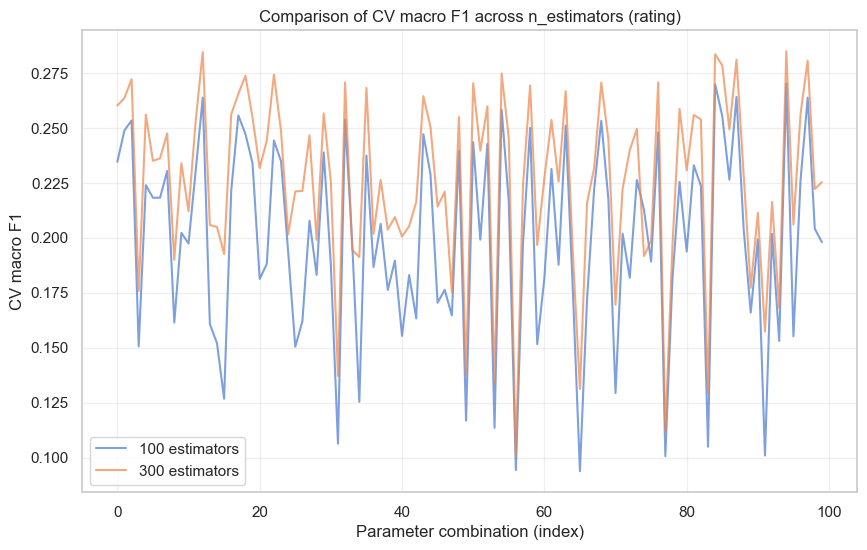

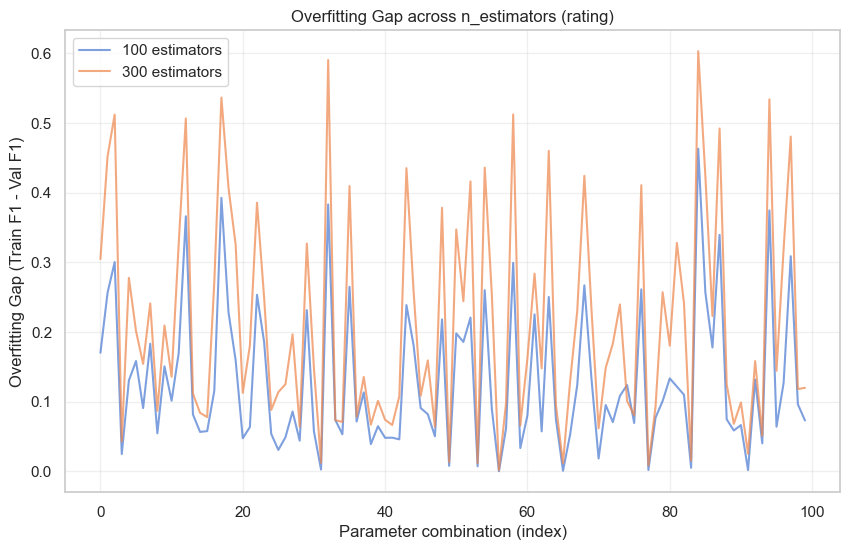

In [31]:
# First plot - CV F1 scores
plt.figure(figsize=(10, 6))
plt.plot(cv_results_rating_100.index, cv_results_rating_100["mean_test_f1_macro"], 
         label="100 estimators", alpha=0.7)
plt.plot(cv_results_rating_300.index, cv_results_rating_300["mean_test_f1_macro"], 
         label="300 estimators", alpha=0.7)
plt.xlabel("Parameter combination (index)")
plt.ylabel("CV macro F1")
plt.title("Comparison of CV macro F1 across n_estimators (rating)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Second plot - Overfitting gap
plt.figure(figsize=(10, 6))
plt.plot(cv_results_rating_100.index, cv_results_rating_100["overfitting_gap"], 
         label="100 estimators", alpha=0.7)
plt.plot(cv_results_rating_300.index, cv_results_rating_300["overfitting_gap"], 
         label="300 estimators", alpha=0.7)
plt.xlabel("Parameter combination (index)")
plt.ylabel("Overfitting Gap (Train F1 - Val F1)")
plt.title("Overfitting Gap across n_estimators (rating)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

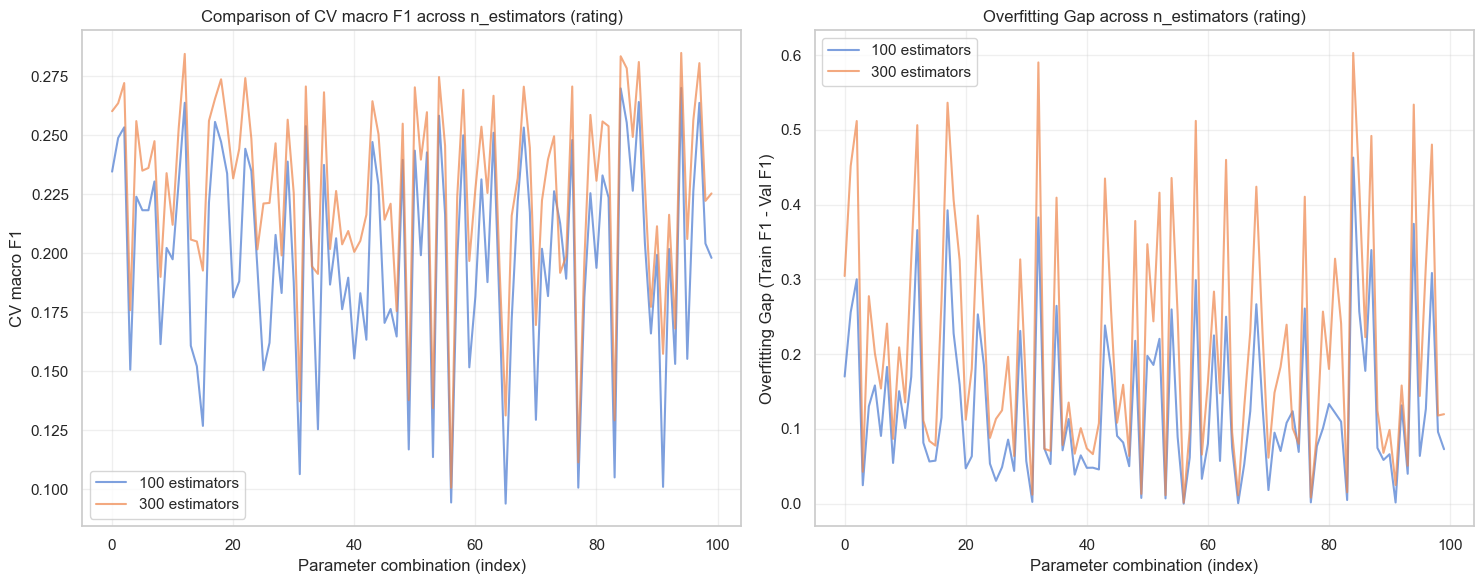

In [28]:
# SAME PLOT SIDE BY SIDE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot CV F1 scores
ax1.plot(cv_results_rating_100.index, cv_results_rating_100["mean_test_f1_macro"], 
         label="100 estimators", alpha=0.7)
ax1.plot(cv_results_rating_300.index, cv_results_rating_300["mean_test_f1_macro"], 
         label="300 estimators", alpha=0.7)
ax1.set_xlabel("Parameter combination (index)")
ax1.set_ylabel("CV macro F1")
ax1.set_title("Comparison of CV macro F1 across n_estimators (rating)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot overfitting gap
ax2.plot(cv_results_rating_100.index, cv_results_rating_100["overfitting_gap"], 
         label="100 estimators", alpha=0.7)
ax2.plot(cv_results_rating_300.index, cv_results_rating_300["overfitting_gap"], 
         label="300 estimators", alpha=0.7)
ax2.set_xlabel("Parameter combination (index)")
ax2.set_ylabel("Overfitting Gap (Train F1 - Val F1)")
ax2.set_title("Overfitting Gap across n_estimators (rating)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


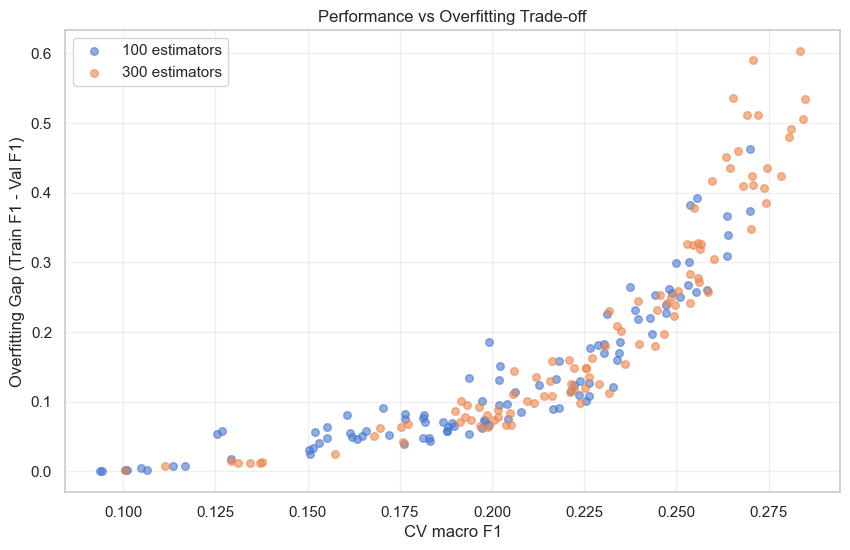

In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(cv_results_rating_100["mean_test_f1_macro"], cv_results_rating_100["overfitting_gap"], 
           alpha=0.6, label="100 estimators", s=30)
plt.scatter(cv_results_rating_300["mean_test_f1_macro"], cv_results_rating_300["overfitting_gap"], 
           alpha=0.6, label="300 estimators", s=30)

plt.xlabel("CV macro F1")
plt.ylabel("Overfitting Gap (Train F1 - Val F1)")
plt.title("Performance vs Overfitting Trade-off")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In this case, the increase in the n. of estimators lead to a gain performance; nevertheless, for both models, overfitting occurs for competitive models: the 'overfitting gap' grows exponentially as validation macro F1 grows. 
We'll test the best performing model (300 estimators) and one with a reasonable trade-off (best performing with gap <0.3)

## Test: best performing model (overfitted)

In [ ]:
lgbm_rating = random_search_rating_300.best_estimator_
#joblib.dump(lgbm_rating, data_dir/"lgbm_rating.pkl")

['..\\..\\results\\lgbm_rating.pkl']

In [38]:
y_pred_rating = lgbm_rating.predict(df_test)
print(classification_report(y_test_rating, y_pred_rating, digits=3))

c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

      (0, 1]      0.571     0.182     0.276        22
      (1, 2]      0.325     0.098     0.150       133
      (2, 3]      0.359     0.088     0.142       374
      (3, 4]      0.295     0.113     0.164      1035
      (4, 5]      0.378     0.183     0.247      2750
      (5, 6]      0.378     0.307     0.339      6270
      (6, 7]      0.422     0.402     0.412     11750
      (7, 8]      0.471     0.733     0.574     14613
      (8, 9]      0.410     0.212     0.279      6591
     (9, 10]      0.493     0.224     0.308      1319

    accuracy                          0.440     44857
   macro avg      0.410     0.254     0.289     44857
weighted avg      0.426     0.440     0.413     44857



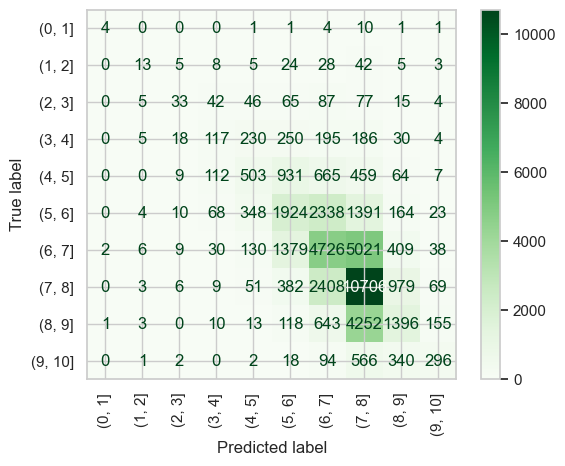

In [39]:
ConfusionMatrixDisplay.from_predictions(y_pred= y_pred_rating, y_true=y_test_rating,                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

Second place: better than SVM, lower than RF.
Confusion matrix: same comments as always. 

In [47]:
best_model = lgbm_rating.named_steps['clf']
preprocessor = lgbm_rating.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

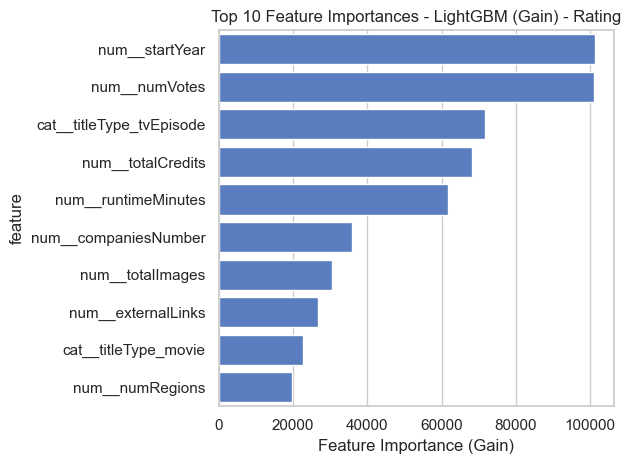

In [63]:
# Get gain importance specifically
gain_importance = best_model.booster_.feature_importance(importance_type='gain')

# Create DataFrame with gain importance
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": gain_importance
}).sort_values(by="importance", ascending=False)

# Plot with gain importance
#plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance_df.head(10), 
            y='feature', x='importance')
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 10 Feature Importances - LightGBM (Gain) - Rating')
plt.tight_layout()
plt.show()

Gain importance measures the total improvement in loss function when a feature is used for splitting.

startYear and numVotes: most impo also for RF; tvEpisode has gained importance (from n. 14 to 3) wrt RF.

c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


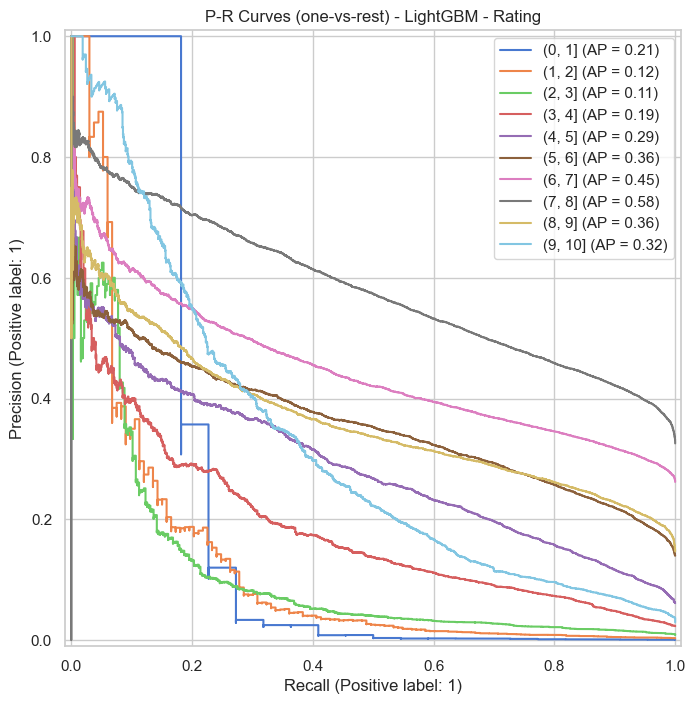

Macro average PR AUC: 0.299


In [64]:
# Get the classes and predictions from your LightGBM model
class_labels = lgbm_rating.classes_
y_score = lgbm_rating.predict_proba(df_test)

# Binarize the test labels for multi-class PR curves
y_test_bin = label_binarize(y_test_rating, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(12, 8))
for i, class_label in enumerate(class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_label}",
        ax=plt.gca()
    )

plt.legend()
plt.title("P-R Curves (one-vs-rest) - LightGBM - Rating")
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score, average='macro'):.3f}")

PR curve: very similar shapes to RF, but slightly lower PR AUC (0.299 vs 0.318)

## Test: tradeoff performance - overfitting
we choose the best model w/ overfitting gap <0.3

79	{'clf__reg_lambda': 1, 'clf__reg_alpha': 1, 'clf__num_leaves': 90, 'clf__n_estimators': 300, 'clf__max_depth': 6, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}	0.515608	0.258593	0.257016


In [65]:
pipeline_rating = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', LGBMClassifier(random_state=42, objective='multiclass', num_class=10, n_estimators=5000)) #large n estimators bc we use early stopping
])

In [66]:
params_79 = cv_results_rating_300.loc[79, 'params']
print(params_79)

pipeline_rating.set_params(**params_79)
pipeline_rating.fit(df_train, y_train_rating)

{'clf__reg_lambda': 1, 'clf__reg_alpha': 1, 'clf__num_leaves': np.int64(90), 'clf__n_estimators': 300, 'clf__max_depth': np.int64(6), 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2099
[LightGBM] [Info] Number of data points in the train set: 104664, number of used features: 110
[LightGBM] [Info] Start training from score -7.368856
[LightGBM] [Info] Start training from score -5.726628
[LightGBM] [Info] Start training from score -4.863948
[LightGBM] [Info] Start training from score -3.771959
[LightGBM] [Info] Start training from score -2.804508
[LightGBM] [Info] Start training from score -1.939045
[LightGBM] [Info] Start training from score -1.344748
[LightGBM] [Info] Start training from score -1.126249
[LightGBM] [Info] Sta

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bool', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
y_pred = pipeline_rating.predict(df_test)
print(classification_report(y_test_rating, y_pred, digits=3))

c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

      (0, 1]      0.800     0.182     0.296        22
      (1, 2]      0.357     0.075     0.124       133
      (2, 3]      0.353     0.032     0.059       374
      (3, 4]      0.369     0.100     0.157      1035
      (4, 5]      0.403     0.160     0.229      2750
      (5, 6]      0.379     0.287     0.327      6270
      (6, 7]      0.410     0.393     0.401     11750
      (7, 8]      0.452     0.763     0.567     14613
      (8, 9]      0.397     0.138     0.205      6591
     (9, 10]      0.521     0.157     0.241      1319

    accuracy                          0.429     44857
   macro avg      0.444     0.229     0.261     44857
weighted avg      0.419     0.429     0.392     44857



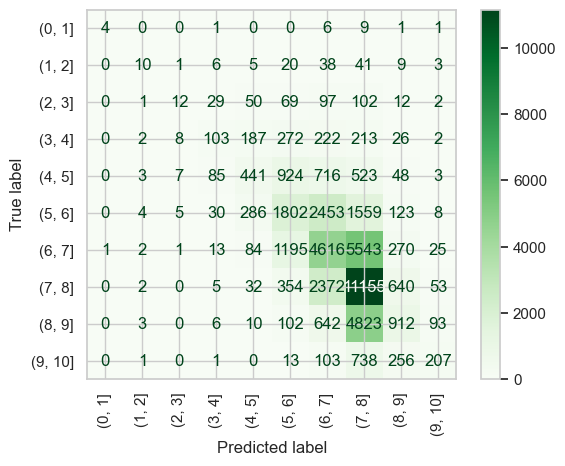

In [68]:
ConfusionMatrixDisplay.from_predictions(y_pred= y_pred, y_true=y_test_rating,                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

Test macro f1: 0.261 vs 0.289 → the overfitted model is better.

# TitleType

## Pre-processing

In [ ]:
# Overwrite
df_train = train.copy()
df_test = test.copy()

In [ ]:
df_train.columns

Index(['originalTitle', 'rating', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber',
       'averageRating', 'regions', 'externalLinks', 'writerCredits',
       'numGenres', 'criticReviewsRatio', 'hasAwards',
       'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

In [ ]:
# drop target variable and rating (we'll use averageRating)
df_train.drop(columns=['rating', 'titleType'], inplace=True) 
df_test.drop(columns=['rating', 'titleType'], inplace=True)

check_columns(df_train, df_test)
df_train.columns

Train and test columns match.


Index(['originalTitle', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'canHaveEpisodes', 'numRegions',
       'countryOfOrigin', 'genres', 'companiesNumber', 'averageRating',
       'regions', 'externalLinks', 'writerCredits', 'numGenres',
       'criticReviewsRatio', 'hasAwards', 'hasAwardsOrNominations',
       'hasVideos', 'hasCriticsReviews', 'hasUserReviews',
       'moreDirectorsCredits', 'hasQuotes', 'moreCountriesOfOrigin'],
      dtype='object')

In [ ]:
# overwrite to make sure they're up to date

num_cols = df_train.dtypes[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')].index
bool_cols = df_train.dtypes[df_train.dtypes == 'bool'].index
cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions']).index #drop the target var and lists

In [ ]:
num_cols, bool_cols, cat_cols

(Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
        'totalCredits', 'numRegions', 'companiesNumber', 'averageRating',
        'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio'],
       dtype='object'),
 Index(['canHaveEpisodes', 'hasAwards', 'hasAwardsOrNominations', 'hasVideos',
        'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
        'hasQuotes', 'moreCountriesOfOrigin'],
       dtype='object'),
 Index([], dtype='object'))

In [ ]:
# Preprocess Lists: countryOfOrigin, genres, regions	
df_train['countryOfOrigin'] = df_train['countryOfOrigin'].apply(ast.literal_eval)
df_train['genres'] = df_train['genres'].apply(ast.literal_eval)
df_train['regions'] = df_train['regions'].apply(ast.literal_eval)

df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['regions'] = df_test['regions'].apply(ast.literal_eval)

df_train['country_cleaned'] = df_train['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)

df_train['region_cleaned'] = df_train['regions'].apply(clean_geo, top_geo=top_regions)
df_test['region_cleaned'] = df_test['regions'].apply(clean_geo, top_geo=top_regions)

## Pipeline

In [ ]:
pipeline_tts = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', LGBMClassifier(random_state=42, objective='multiclass', num_class=10))
])

## Hyperparameter Tuning

In [ ]:
param_list_100 = {
    'clf__n_estimators': [100],
    'clf__boosting_type': ['gbdt', 'goss', 'dart'],
    'clf__num_leaves': np.arange(20, 100, 10),
    'clf__max_depth': [-1] + list(np.arange(3, 13)),
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__reg_alpha': [0, 0.01, 0.1, 1],
    'clf__reg_lambda': [0, 0.01, 0.1, 1]
}

param_list_300 = {
    'clf__n_estimators': [300],
    'clf__boosting_type': ['gbdt', 'goss', 'dart'],
    'clf__num_leaves': np.arange(20, 100, 10),
    'clf__max_depth': [-1] + list(np.arange(3, 13)),
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__reg_alpha': [0, 0.01, 0.1, 1],
    'clf__reg_lambda': [0, 0.01, 0.1, 1]
}

In [ ]:
random_search_tts_100 = RandomizedSearchCV(
    pipeline_tts,
    param_distributions=param_list_100,
    n_iter=100,
    cv=3,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_tts_100.fit(df_train, y_train_titleType)

print(f"BEST MODEL:")
best_index_titleType_100 = random_search_tts_100.best_index_
train_macro_f1_titleType_100 = random_search_tts_100.cv_results_['mean_train_f1_macro'][best_index_titleType_100]

print(f"Validation macro F1: {random_search_tts_100.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_titleType_100:.3f}")
print(f"Best parameters: {random_search_tts_100.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2099
[LightGBM] [Info] Number of data points in the train set: 104664, number of used features: 110
[LightGBM] [Info] Start training from score -7.368856
[LightGBM] [Info] Start training from score -5.726628
[LightGBM] [Info] Start training from score -4.863948
[LightGBM] [Info] Start training from score -3.771959
[LightGBM] [Info] Start training from score -2.804508
[LightGBM] [Info] Start training from score -1.939045
[LightGBM] [Info] Start training from score -1.344748
[LightGBM] [Info] Start training from score -1.126249
[LightGBM] [Info] Start training from score -1.911529
[LightGBM] [Info] Start training from score -3.564891
[LightGBM] [Warning] No further splits wit

In [ ]:
cv_results_tts_100 = pd.DataFrame(random_search_tts_100.cv_results_)
cv_results_tts_100['overfitting_gap'] = cv_results_tts_100['mean_train_f1_macro'] - cv_results_tts_100['mean_test_f1_macro']

In [ ]:
pd.set_option("display.max_colwidth", None)

In [ ]:
cv_results_tts_100.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(25)[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']]

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
94,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 0.01, 'clf__num_leaves': 50, 'clf__n_estimators': 100, 'clf__max_depth': 10, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.644436,0.270036,0.374401
84,"{'clf__reg_lambda': 0.01, 'clf__reg_alpha': 0, 'clf__num_leaves': 70, 'clf__n_estimators': 100, 'clf__max_depth': -1, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.732852,0.269845,0.463006
87,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 0.01, 'clf__num_leaves': 70, 'clf__n_estimators': 100, 'clf__max_depth': 12, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}",0.603396,0.264079,0.339317
12,"{'clf__reg_lambda': 0.01, 'clf__reg_alpha': 0, 'clf__num_leaves': 70, 'clf__n_estimators': 100, 'clf__max_depth': -1, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}",0.629754,0.263740,0.366014
97,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 1, 'clf__num_leaves': 40, 'clf__n_estimators': 100, 'clf__max_depth': 10, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.572371,0.263702,0.308669
54,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 1, 'clf__num_leaves': 60, 'clf__n_estimators': 100, 'clf__max_depth': 10, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}",0.518215,0.258258,0.259957
17,"{'clf__reg_lambda': 0, 'clf__reg_alpha': 0, 'clf__num_leaves': 70, 'clf__n_estimators': 100, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.648159,0.255636,0.392523
85,"{'clf__reg_lambda': 1, 'clf__reg_alpha': 0.1, 'clf__num_leaves': 30, 'clf__n_estimators': 100, 'clf__max_depth': 12, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.512425,0.255311,0.257114
32,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 0, 'clf__num_leaves': 90, 'clf__n_estimators': 100, 'clf__max_depth': 11, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'goss'}",0.636771,0.253817,0.382955
2,"{'clf__reg_lambda': 0.01, 'clf__reg_alpha': 0.01, 'clf__num_leaves': 90, 'clf__n_estimators': 100, 'clf__max_depth': 12, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'goss'}",0.553583,0.253343,0.300241


In [ ]:
random_search_tts_300 = RandomizedSearchCV(
    pipeline_tts,
    param_distributions=param_list_300,
    n_iter=100,
    cv=3,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_tts_300.fit(df_train, y_train_titleType)

print(f"BEST MODEL:")
best_index_titleType_300 = random_search_tts_300.best_index_
train_macro_f1_titleType_300 = random_search_tts_300.cv_results_['mean_train_f1_macro'][best_index_titleType_300]

print(f"Validation macro F1: {random_search_tts_300.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_titleType_300:.3f}")
print(f"Best parameters: {random_search_tts_300.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031349 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2099
[LightGBM] [Info] Number of data points in the train set: 104664, number of used features: 110
[LightGBM] [Info] Start training from score -7.368856
[LightGBM] [Info] Start training from score -5.726628
[LightGBM] [Info] Start training from score -4.863948
[LightGBM] [Info] Start training from score -3.771959
[LightGBM] [Info] Start training from score -2.804508
[LightGBM] [Info] Start training from score -1.939045
[LightGBM] [Info] Start training from score -1.344748
[LightGBM] [Info] Start training from score -1.126249
[LightGBM] [Info] Start training from score -1.911529
[LightGBM] [Info] Start training from score -3.564891
[LightGBM] [Warning] No further splits wit

In [ ]:
cv_results_tts_300 = pd.DataFrame(random_search_tts_300.cv_results_)
cv_results_tts_300['overfitting_gap'] = cv_results_tts_300['mean_train_f1_macro'] - cv_results_tts_300['mean_test_f1_macro']

In [ ]:
cv_results_tts_300.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(25)[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']]

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
94,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 0.01, 'clf__num_leaves': 50, 'clf__n_estimators': 300, 'clf__max_depth': 10, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.818706,0.284862,0.533844
12,"{'clf__reg_lambda': 0.01, 'clf__reg_alpha': 0, 'clf__num_leaves': 70, 'clf__n_estimators': 300, 'clf__max_depth': -1, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}",0.790843,0.284455,0.506388
84,"{'clf__reg_lambda': 0.01, 'clf__reg_alpha': 0, 'clf__num_leaves': 70, 'clf__n_estimators': 300, 'clf__max_depth': -1, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.886427,0.283456,0.602971
87,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 0.01, 'clf__num_leaves': 70, 'clf__n_estimators': 300, 'clf__max_depth': 12, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}",0.773032,0.281020,0.492012
97,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 1, 'clf__num_leaves': 40, 'clf__n_estimators': 300, 'clf__max_depth': 10, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.760953,0.280550,0.480403
85,"{'clf__reg_lambda': 1, 'clf__reg_alpha': 0.1, 'clf__num_leaves': 30, 'clf__n_estimators': 300, 'clf__max_depth': 12, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.702672,0.278377,0.424295
54,"{'clf__reg_lambda': 0.1, 'clf__reg_alpha': 1, 'clf__num_leaves': 60, 'clf__n_estimators': 300, 'clf__max_depth': 10, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'gbdt'}",0.710384,0.274642,0.435742
22,"{'clf__reg_lambda': 0, 'clf__reg_alpha': 0, 'clf__num_leaves': 60, 'clf__n_estimators': 300, 'clf__max_depth': 10, 'clf__learning_rate': 0.03, 'clf__boosting_type': 'gbdt'}",0.659672,0.274204,0.385468
18,"{'clf__reg_lambda': 1, 'clf__reg_alpha': 0, 'clf__num_leaves': 90, 'clf__n_estimators': 300, 'clf__max_depth': 6, 'clf__learning_rate': 0.1, 'clf__boosting_type': 'gbdt'}",0.680284,0.273700,0.406584
2,"{'clf__reg_lambda': 0.01, 'clf__reg_alpha': 0.01, 'clf__num_leaves': 90, 'clf__n_estimators': 300, 'clf__max_depth': 12, 'clf__learning_rate': 0.05, 'clf__boosting_type': 'goss'}",0.784004,0.272098,0.511906


In [ ]:
#"""
cv_results_tts_100.to_csv(data_dir/"cv_results_tts_100_lgbm.csv", index=False)
cv_results_tts_300.to_csv(data_dir/"cv_results_tts_300_lgbm.csv", index=False)
#"""

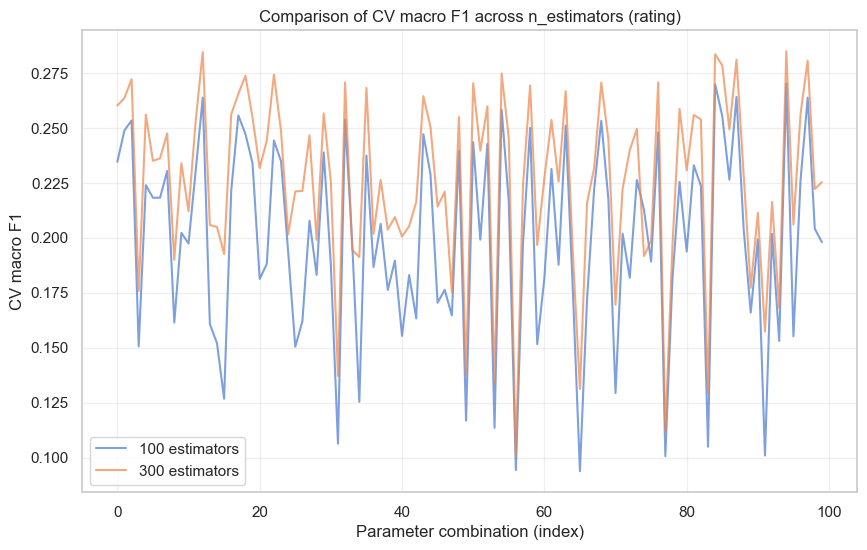

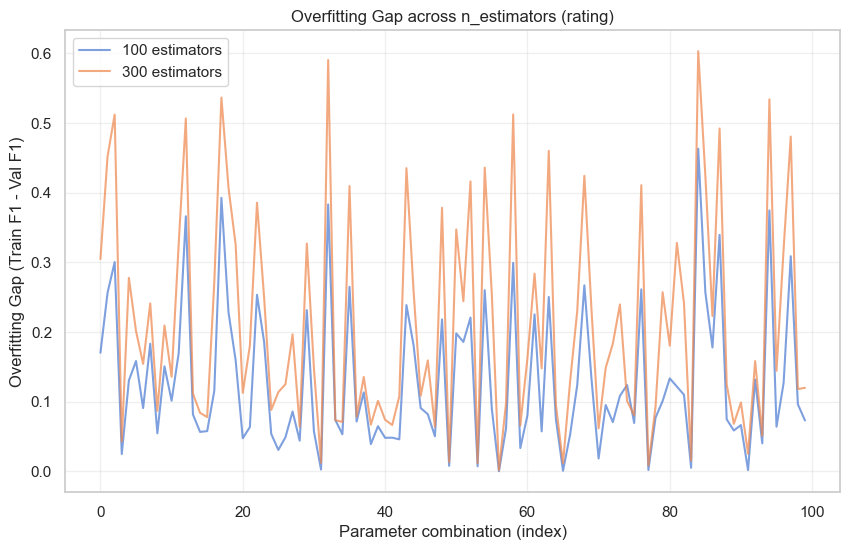

In [ ]:
# First plot - CV F1 scores for titleType
plt.figure(figsize=(10, 6))
plt.plot(cv_results_tts_100.index, cv_results_tts_100["mean_test_f1_macro"], 
         label="100 estimators", alpha=0.7)
plt.plot(cv_results_tts_300.index, cv_results_tts_300["mean_test_f1_macro"], 
         label="300 estimators", alpha=0.7)
plt.xlabel("Parameter combination (index)")
plt.ylabel("CV macro F1")
plt.title("Comparison of CV macro F1 across n_estimators (titleType)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Second plot - Overfitting gap for titleType
plt.figure(figsize=(10, 6))
plt.plot(cv_results_tts_100.index, cv_results_tts_100["overfitting_gap"], 
         label="100 estimators", alpha=0.7)
plt.plot(cv_results_tts_300.index, cv_results_tts_300["overfitting_gap"], 
         label="300 estimators", alpha=0.7)
plt.xlabel("Parameter combination (index)")
plt.ylabel("Overfitting Gap (Train F1 - Val F1)")
plt.title("Overfitting Gap across n_estimators (titleType)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

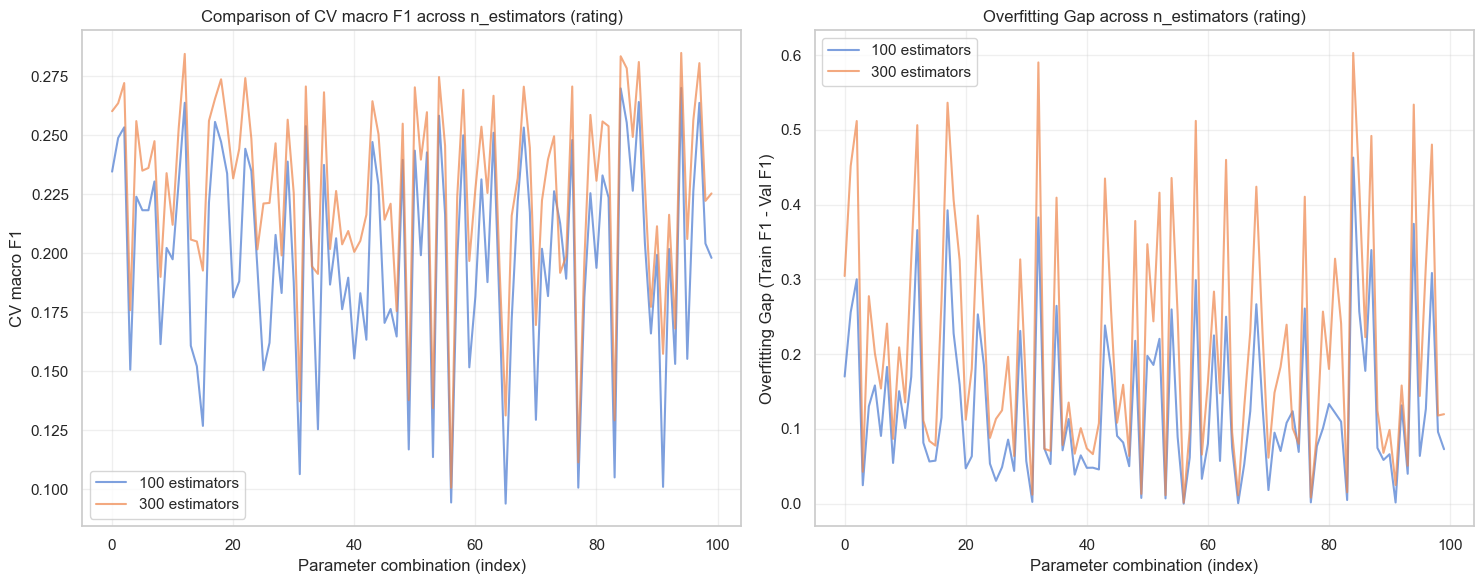

In [ ]:
# SAME PLOT SIDE BY SIDE for titleType
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot CV F1 scores
ax1.plot(cv_results_tts_100.index, cv_results_tts_100["mean_test_f1_macro"], 
         label="100 estimators", alpha=0.7)
ax1.plot(cv_results_tts_300.index, cv_results_tts_300["mean_test_f1_macro"], 
         label="300 estimators", alpha=0.7)
ax1.set_xlabel("Parameter combination (index)")
ax1.set_ylabel("CV macro F1")
ax1.set_title("Comparison of CV macro F1 across n_estimators (titleType)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot overfitting gap
ax2.plot(cv_results_tts_100.index, cv_results_tts_100["overfitting_gap"], 
         label="100 estimators", alpha=0.7)
ax2.plot(cv_results_tts_300.index, cv_results_tts_300["overfitting_gap"], 
         label="300 estimators", alpha=0.7)
ax2.set_xlabel("Parameter combination (index)")
ax2.set_ylabel("Overfitting Gap (Train F1 - Val F1)")
ax2.set_title("Overfitting Gap across n_estimators (titleType)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

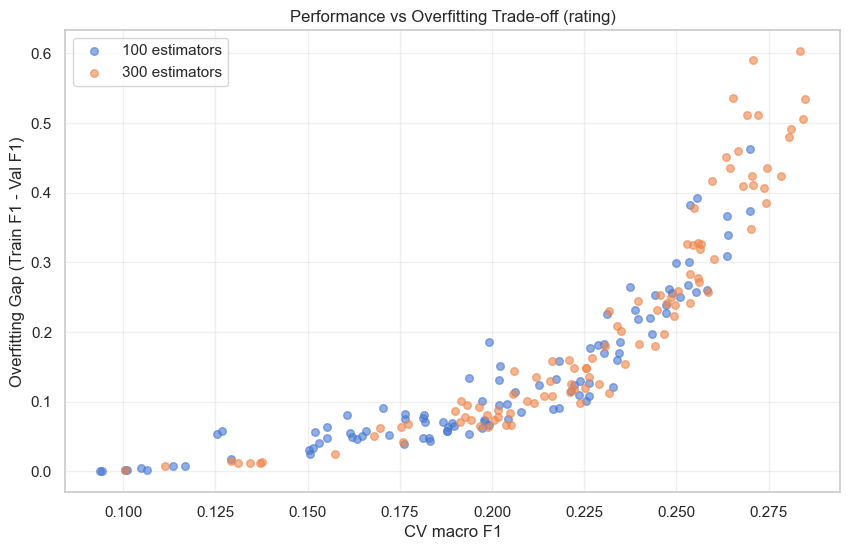

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(cv_results_tts_100["mean_test_f1_macro"], cv_results_tts_100["overfitting_gap"], 
           alpha=0.6, label="100 estimators", s=30)
plt.scatter(cv_results_tts_300["mean_test_f1_macro"], cv_results_tts_300["overfitting_gap"], 
           alpha=0.6, label="300 estimators", s=30)

plt.xlabel("CV macro F1")
plt.ylabel("Overfitting Gap (Train F1 - Val F1)")
plt.title("Performance vs Overfitting Trade-off (titleType)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

AGGIORNA PER TITLETYPE

In this case, the increase in the n. of estimators lead to a gain performance; nevertheless, for both models, overfitting occurs for competitive models: the 'overfitting gap' grows exponentially as validation macro F1 grows. 
We'll test the best performing model (300 estimators) and one with a reasonable trade-off (best performing with gap <0.3)

## Test: best performing model 

In [ ]:
#lgbm_tts = random_search_tts_300.best_estimator_
#joblib.dump(lgbm_tts, data_dir/"lgbm_tts.pkl")

['..\\..\\results\\lgbm_rating.pkl']

In [ ]:
y_pred_tts = lgbm_tts.predict(df_test)
print(classification_report(y_test_titleType, y_pred_tts, digits=3))

c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

      (0, 1]      0.571     0.182     0.276        22
      (1, 2]      0.325     0.098     0.150       133
      (2, 3]      0.359     0.088     0.142       374
      (3, 4]      0.295     0.113     0.164      1035
      (4, 5]      0.378     0.183     0.247      2750
      (5, 6]      0.378     0.307     0.339      6270
      (6, 7]      0.422     0.402     0.412     11750
      (7, 8]      0.471     0.733     0.574     14613
      (8, 9]      0.410     0.212     0.279      6591
     (9, 10]      0.493     0.224     0.308      1319

    accuracy                          0.440     44857
   macro avg      0.410     0.254     0.289     44857
weighted avg      0.426     0.440     0.413     44857



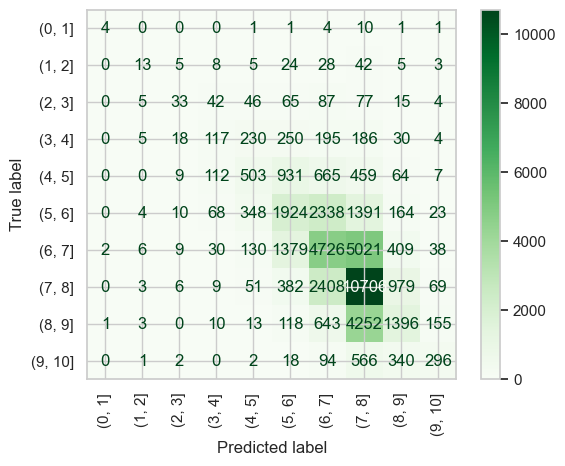

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_pred= y_pred_tts, y_true=y_test_titleType,                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

Second place: better than SVM, lower than RF.
Confusion matrix: same comments as always. 

In [ ]:
best_model = lgbm_tts.named_steps['clf']
preprocessor = lgbm_tts.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

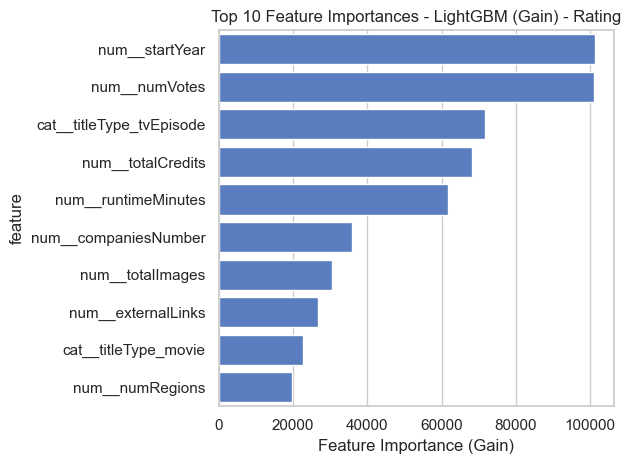

In [ ]:
# Get gain importance specifically
gain_importance = best_model.booster_.feature_importance(importance_type='gain')

# Create DataFrame with gain importance
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": gain_importance
}).sort_values(by="importance", ascending=False)

# Plot with gain importance
#plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance_df.head(10), 
            y='feature', x='importance')
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 10 Feature Importances - LightGBM (Gain) - TitleType')
plt.tight_layout()
plt.show()

AGGIORNA PER TITLE TYPE

Gain importance measures the total improvement in loss function when a feature is used for splitting.

startYear and numVotes: most impo also for RF; tvEpisode has gained importance (from n. 14 to 3) wrt RF.

c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


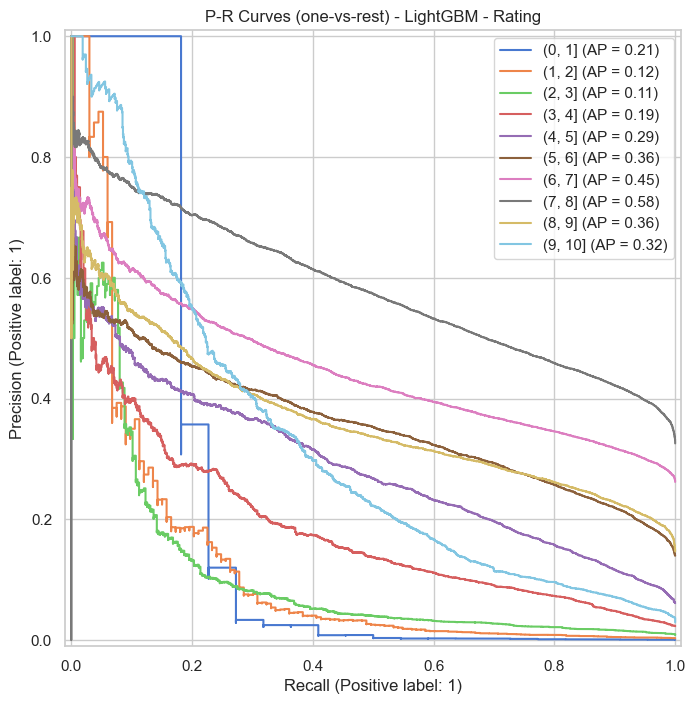

Macro average PR AUC: 0.299


In [ ]:
# Get the classes and predictions from your LightGBM model
class_labels = lgbm_tts.classes_
y_score = lgbm_tts.predict_proba(df_test)

# Binarize the test labels for multi-class PR curves
y_test_bin = label_binarize(y_test_titleType, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(12, 8))
for i, class_label in enumerate(class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_label}",
        ax=plt.gca()
    )

plt.legend()
plt.title("P-R Curves (one-vs-rest) - LightGBM - TitleType")
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score, average='macro'):.3f}")

PR curve: very similar shapes to RF, but slightly lower PR AUC (0.299 vs 0.318)